In [8]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("D:\samples_data.csv")
df

,id,name,age,gender,salary,join_date,department,score
0,1,Alice,25.0,F,50000.0,2021-05-10,Sales,88.0
1,2,Bob,30.0,M,62000.0,2020/03/15,HR,92.0
2,3,Charlie,NaN,M,58000.0,15-07-2019,IT,79.0
3,4,david,45.0,male,NaN,IT,NaN,NaN
4,5,Eve,-3.0,F,72000.0,2022-13-01,NaN,65.0
5,5,Eve,200.0,NaN,1000000.0,2018-11-20,Finance,300.0
6,7,Frank,33.0,M,54000.0,wrong_date,finance,73.0
7,8,NaN,29.0,FEMALE,51000.0,2021-09-01,Sales,85.0
8,9,Grace,NaN,F,49000.0,2020/12/01,SALES,90.0
9,10,Henry,41.0,Unknown,NaN,2017-05-05,IT,82.0


# cleaning 

In [3]:
df['gender'].unique()

array(['F', 'M', 'male', nan, 'FEMALE', 'Unknown'], dtype=object)

In [4]:
df['department'].unique()

array(['Sales', 'HR', 'IT', nan, 'Finance', 'finance', 'SALES'],
      dtype=object)

In [3]:
df['gender']=df['gender'].map({'M':'male','F':'female','FEMALE':'female','male':'male','unknown':np.nan})
df['department']=df['department'].map({'SALES':'sales','Sales':'sales','Finance':'finance','HR':'HR','IT':'IT'})

In [4]:
df

,id,name,age,gender,salary,join_date,department,score
0,1,Alice,25.0,female,50000.0,2021-05-10,sales,88.0
1,2,Bob,30.0,male,62000.0,2020/03/15,HR,92.0
2,3,Charlie,NaN,male,58000.0,15-07-2019,IT,79.0
3,4,david,45.0,male,NaN,IT,NaN,NaN
4,5,Eve,-3.0,female,72000.0,2022-13-01,NaN,65.0
5,5,Eve,200.0,NaN,1000000.0,2018-11-20,finance,300.0
6,7,Frank,33.0,male,54000.0,wrong_date,NaN,73.0
7,8,NaN,29.0,female,51000.0,2021-09-01,sales,85.0
8,9,Grace,NaN,female,49000.0,2020/12/01,sales,90.0
9,10,Henry,41.0,NaN,NaN,2017-05-05,IT,82.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          10 non-null     int64  
 1   name        9 non-null      object 
 2   age         8 non-null      float64
 3   gender      8 non-null      object 
 4   salary      8 non-null      float64
 5   join_date   10 non-null     object 
 6   department  7 non-null      object 
 7   score       9 non-null      float64
dtypes: float64(3), int64(1), object(4)
memory usage: 772.0+ bytes


In [ ]:
Your values look like:

2021-05-10 → %Y-%m-%d

2020/03/15 → %Y/%m/%d

15-07-2019 → %d-%m-%Y

2022-13-01 → invalid

wrong_date → invalid

IT → not a date

In [4]:
df["join_date_clean"] = pd.to_datetime(
    df["join_date"],
    format="mixed",
    errors="coerce", #If conversion fails, don’t crash → replace with a safe value (usually NaN).
    dayfirst=True
)

In [11]:
df

,id,name,age,gender,salary,join_date,department,score,join_date_clean
0,1,Alice,25.0,female,50000.0,2021-05-10,sales,88.0,2021-05-10
1,2,Bob,30.0,male,62000.0,2020/03/15,HR,92.0,2020-03-15
2,3,Charlie,NaN,male,58000.0,15-07-2019,IT,79.0,2019-07-15
3,4,david,45.0,male,NaN,IT,NaN,NaN,NaT
4,5,Eve,-3.0,female,72000.0,2022-13-01,NaN,65.0,2022-01-13
5,5,Eve,200.0,NaN,1000000.0,2018-11-20,finance,300.0,2018-11-20
6,7,Frank,33.0,male,54000.0,wrong_date,NaN,73.0,NaT
7,8,NaN,29.0,female,51000.0,2021-09-01,sales,85.0,2021-09-01
8,9,Grace,NaN,female,49000.0,2020/12/01,sales,90.0,2020-12-01
9,10,Henry,41.0,NaN,NaN,2017-05-05,IT,82.0,2017-05-05


In [7]:
import pandas as pd

s = pd.Series(["10", "20", "abc", "30"])

pd.to_numeric(s,errors='coerce')

0    10.0
1    20.0
2     NaN
3    30.0
dtype: float64

In [5]:
df["join_year"] = df["join_date_clean"].dt.year

In [6]:
df

,id,name,age,gender,salary,join_date,department,score,join_date_clean,join_year
0,1,Alice,25.0,female,50000.0,2021-05-10,sales,88.0,2021-05-10,2021.0
1,2,Bob,30.0,male,62000.0,2020/03/15,HR,92.0,2020-03-15,2020.0
2,3,Charlie,NaN,male,58000.0,15-07-2019,IT,79.0,2019-07-15,2019.0
3,4,david,45.0,male,NaN,IT,NaN,NaN,NaT,NaN
4,5,Eve,-3.0,female,72000.0,2022-13-01,NaN,65.0,2022-01-13,2022.0
5,5,Eve,200.0,NaN,1000000.0,2018-11-20,finance,300.0,2018-11-20,2018.0
6,7,Frank,33.0,male,54000.0,wrong_date,NaN,73.0,NaT,NaN
7,8,NaN,29.0,female,51000.0,2021-09-01,sales,85.0,2021-09-01,2021.0
8,9,Grace,NaN,female,49000.0,2020/12/01,sales,90.0,2020-12-01,2020.0
9,10,Henry,41.0,NaN,NaN,2017-05-05,IT,82.0,2017-05-05,2017.0


In [9]:
df['join_date_clean'].isnull().sum()

np.int64(2)

# Group by department and get average salary

In [ ]:
# make agroup on the basis of catrgorical column


In [10]:
dept=df.groupby("department")

In [11]:
dept

In [12]:
dept.size() # count the no of rows in each group

department
HR         1
IT         2
finance    1
sales      3
dtype: int64

In [13]:
dept.first() # give the first row

,id,name,age,gender,salary,join_date,score,join_date_clean
department,,,,,,,,
HR,2,Bob,30.0,male,62000.0,2020/03/15,92.0,2020-03-15
IT,3,Charlie,41.0,male,58000.0,15-07-2019,79.0,2019-07-15
finance,5,Eve,200.0,None,1000000.0,2018-11-20,300.0,2018-11-20
sales,1,Alice,25.0,female,50000.0,2021-05-10,88.0,2021-05-10


In [14]:
dept.last()

,id,name,age,gender,salary,join_date,score,join_date_clean
department,,,,,,,,
HR,2,Bob,30.0,male,62000.0,2020/03/15,92.0,2020-03-15
IT,10,Henry,41.0,male,58000.0,2017-05-05,82.0,2017-05-05
finance,5,Eve,200.0,None,1000000.0,2018-11-20,300.0,2018-11-20
sales,9,Grace,29.0,female,49000.0,2020/12/01,90.0,2020-12-01


In [15]:
# Access a single group (e.g., “IT” department)
dept.get_group("sales")

,id,name,age,gender,salary,join_date,department,score,join_date_clean
0,1,Alice,25.0,female,50000.0,2021-05-10,sales,88.0,2021-05-10
7,8,NaN,29.0,female,51000.0,2021-09-01,sales,85.0,2021-09-01
8,9,Grace,NaN,female,49000.0,2020/12/01,sales,90.0,2020-12-01


# SCENARIO 1 — Group by department & compute average salary

In [16]:
dept = df.groupby("department")['salary'].mean()

In [17]:
dept

department
HR           62000.0
IT           58000.0
finance    1000000.0
sales        50000.0
Name: salary, dtype: float64

#  SCENARIO 2 — Group by department & compute total salary

In [18]:
dept = df.groupby("department")['salary'].sum()
dept

department
HR           62000.0
IT           58000.0
finance    1000000.0
sales       150000.0
Name: salary, dtype: float64

In [18]:
dept = df.groupby("department").sum()['salary'].sort_values(ascending=False).head(3)
dept

department
Finance    1000000.0
Sales       101000.0
HR           62000.0
Name: salary, dtype: float64

# SCENARIO 3 — Group by gender with normalized category

In [37]:
df.groupby("gender")["age"].mean()


gender
female    17.0
male      36.0
Name: age, dtype: float64

In [ ]:
# SCENARIO 4 — Group by department and get multiple aggregations

In [20]:
df.groupby("department").agg({
    "salary": ["mean", "min", "max"],
    "score": "mean"
})

salary                             score
                 mean        min        max        mean
department                                             
HR            62000.0    62000.0    62000.0   92.000000
IT            58000.0    58000.0    58000.0   80.500000
finance     1000000.0  1000000.0  1000000.0  300.000000
sales         50000.0    49000.0    51000.0   87.666667

# handle the age column

In [28]:
df['age']

0     25.0
1     30.0
2      NaN
3     45.0
4     -3.0
5    200.0
6     33.0
7     29.0
8      NaN
9     41.0
Name: age, dtype: float64

In [5]:
df["age_clean"] = df["age"].apply(lambda x: np.nan if x < 0 or x > 120 else x)

In [6]:
df["age_group"] = pd.cut(df["age_clean"], bins=[0,20,30,40,50,100],
                         labels=["teenager","adults","working adults","old","old age"])

In [7]:
df

,id,name,age,gender,salary,join_date,department,score,join_date_clean,age_clean,age_group
0,1,Alice,25.0,female,50000.0,2021-05-10,sales,88.0,2021-05-10,25.0,adults
1,2,Bob,30.0,male,62000.0,2020/03/15,HR,92.0,2020-03-15,30.0,adults
2,3,Charlie,NaN,male,58000.0,15-07-2019,IT,79.0,2019-07-15,NaN,NaN
3,4,david,45.0,male,NaN,IT,NaN,NaN,NaT,45.0,old
4,5,Eve,-3.0,female,72000.0,2022-13-01,NaN,65.0,2022-01-13,NaN,NaN
5,5,Eve,200.0,NaN,1000000.0,2018-11-20,finance,300.0,2018-11-20,NaN,NaN
6,7,Frank,33.0,male,54000.0,wrong_date,NaN,73.0,NaT,33.0,working adults
7,8,NaN,29.0,female,51000.0,2021-09-01,sales,85.0,2021-09-01,29.0,adults
8,9,Grace,NaN,female,49000.0,2020/12/01,sales,90.0,2020-12-01,NaN,NaN
9,10,Henry,41.0,NaN,NaN,2017-05-05,IT,82.0,2017-05-05,41.0,old


In [10]:
df.groupby("age_group")["salary"].mean()

C:\Users\complere\AppData\Local\Temp\ipykernel_14516\1231005768.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["salary"].mean()


age_group
teenager                   NaN
adults            54333.333333
working adults    54000.000000
old                        NaN
old age                    NaN
Name: salary, dtype: float64

In [48]:
df.groupby("age_group")["salary"].count()

C:\Users\complere\AppData\Local\Temp\ipykernel_16212\462720326.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["salary"].count()


age_group
0–20     0
21–30    3
31–40    1
41–50    0
50+      0
Name: salary, dtype: int64

# Group by department & gender together

In [25]:
df.groupby(["department", "gender"])["salary"].mean()

department  gender
HR          male      62000.0
IT          male      58000.0
sales       female    50000.0
Name: salary, dtype: float64

# pivot (convert rows to column)

In [ ]:
pivot() is used to reshape data — it converts rows into columns based on unique values.
rows-------------> column                       pivot   (long format----------> wide format)
column------------> row                          melt   (wide format ---------------> long format)
continuous column-------------> category        cut 

In [ ]:
Parameter	Meaning
index	What becomes the new row labels
columns	What becomes the new column labels
values	What fills the table

In [9]:
df

,id,name,age,gender,salary,join_date,department,score,join_date_clean,age_clean,age_group
0,1,Alice,25.0,female,50000.0,2021-05-10,sales,88.0,2021-05-10,25.0,adults
1,2,Bob,30.0,male,62000.0,2020/03/15,HR,92.0,2020-03-15,30.0,adults
2,3,Charlie,NaN,male,58000.0,15-07-2019,IT,79.0,2019-07-15,NaN,NaN
3,4,david,45.0,male,NaN,IT,NaN,NaN,NaT,45.0,old
4,5,Eve,-3.0,female,72000.0,2022-13-01,NaN,65.0,2022-01-13,NaN,NaN
5,5,Eve,200.0,NaN,1000000.0,2018-11-20,finance,300.0,2018-11-20,NaN,NaN
6,7,Frank,33.0,male,54000.0,wrong_date,NaN,73.0,NaT,33.0,working adults
7,8,NaN,29.0,female,51000.0,2021-09-01,sales,85.0,2021-09-01,29.0,adults
8,9,Grace,NaN,female,49000.0,2020/12/01,sales,90.0,2020-12-01,NaN,NaN
9,10,Henry,41.0,NaN,NaN,2017-05-05,IT,82.0,2017-05-05,41.0,old


In [54]:
#Pivot Table With Two Dimensions(convert rows to columns)(deep analysis)
#Example: Average salary by department & gender
pd.pivot_table(
    df,
    values="salary",
    index="department",    # department,gender
    columns="gender",
    aggfunc="mean"
)

gender,female,male
department,,
HR,NaN,62000.0
IT,NaN,58000.0
sales,50000.0,NaN


In [11]:
#Pivot Table With Multiple Aggregations
#Example: Calculate mean salary, max score, and count of employees per department
pd.pivot_table(
    df,
    values=["salary", "score"],
    index="department",
    columns="gender",
    aggfunc={"salary": "mean", "score": ["max","min"]}
)

salary           score                   
               mean             max          min      
gender       female     male female  male female  male
department                                            
HR              NaN  62000.0    NaN  92.0    NaN  92.0
IT              NaN  58000.0    NaN  79.0    NaN  79.0
sales       50000.0      NaN   90.0   NaN   85.0   NaN

<Axes: xlabel='department'>

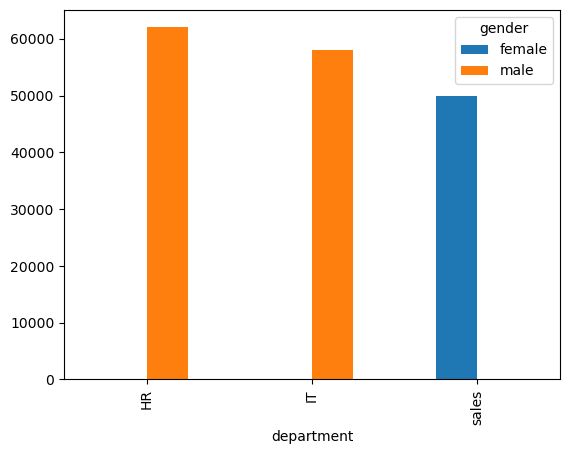

In [64]:
# Average salary by department and gender
pd.pivot_table(
    df,
    values="salary",
    index="department",
    columns="gender",
    aggfunc="mean",
    fill_value=0
).plot(kind='bar')


In [ ]:
melt
#reshape the data ,unpivot the dataframe from( wide format ------> long format)
# col----->row
It is one of the most important functions when preparing data for visualization (especially in Seaborn)

In [ ]:
subject  Math  Science
student                
A          90       85
B          80       88

In [ ]:
  student  subject  marks                       
0       A     Math     90             
1       A  Science     85
2       B     Math     80
3       B  Science     88

In [15]:
df1 = pd.DataFrame({
    'batsman': ['Kohli', 'Rohit'],
    'country':['india','us'],
    '2015': [400, 450],
    '2016': [500, 480],
    '2017': [600, 520]
})
df1

,batsman,country,2015,2016,2017
0,Kohli,india,400,500,600
1,Rohit,us,450,480,520


In [18]:
long_df = df1.melt(
    id_vars=['batsman','country'],
    var_name='Year',
    value_name='a'
)

long_df

,batsman,country,Year,a
0,Kohli,india,2015,400
1,Rohit,us,2015,450
2,Kohli,india,2016,500
3,Rohit,us,2016,480
4,Kohli,india,2017,600
5,Rohit,us,2017,520


<Axes: xlabel='batsman,Year'>

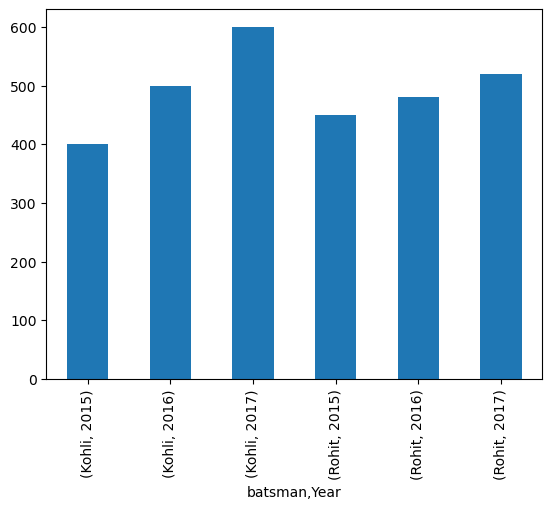

In [20]:
long_df.groupby(["batsman","Year"])["a"].sum().plot(kind="bar")


# merging

In [21]:
import numpy as np

In [22]:
df1 = pd.DataFrame({
    "id": [1, 2, 3, 4, np.nan],
    "name": ["Alice", "Bob", None, "David", "Eva"],
    "department": ["Sales", None, "IT", "Finance", "HR"]
})

In [21]:
df1

,id,name,department
0,1.0,Alice,Sales
1,2.0,Bob,None
2,3.0,None,IT
3,4.0,David,Finance
4,NaN,Eva,HR


In [23]:
df2 = pd.DataFrame({
    "id": [1, 2, None, 5, 3],
    "salary": [50000, np.nan, 58000, 70000, None],
    "join_date": ["2021-05-10", None, "2019-09-01", "2022-01-01", None]
})

In [23]:
df2

,id,salary,join_date
0,1.0,50000.0,2021-05-10
1,2.0,NaN,None
2,NaN,58000.0,2019-09-01
3,5.0,70000.0,2022-01-01
4,3.0,NaN,None


In [ ]:
#   Merge results (inner/left/right/outer)
✅ How NaN affects merges
✅ Fill missing values after merging
✅ Plot missing-data heatmaps

In [24]:
print(df1)
print(df2)

    id   name department
0  1.0  Alice      Sales
1  2.0    Bob       None
2  3.0   None         IT
3  4.0  David    Finance
4  NaN    Eva         HR
    id   salary   join_date
0  1.0  50000.0  2021-05-10
1  2.0      NaN        None
2  NaN  58000.0  2019-09-01
3  5.0  70000.0  2022-01-01
4  3.0      NaN        None


In [48]:
#INNER JOIN
#Only rows where id matches AND is not null.

inner = pd.merge(df1, df2, on="id", how="inner")
inner

,id,name,department,salary,join_date
0,1.0,Alice,Sales,50000.0,2021-05-10
1,2.0,Bob,None,NaN,None
2,3.0,None,IT,NaN,None
3,NaN,Eva,HR,58000.0,2019-09-01


In [49]:
left = pd.merge(df1, df2, on="id", how="left")
left

,id,name,department,salary,join_date
0,1.0,Alice,Sales,50000.0,2021-05-10
1,2.0,Bob,None,NaN,None
2,3.0,None,IT,NaN,None
3,4.0,David,Finance,NaN,NaN
4,NaN,Eva,HR,58000.0,2019-09-01


In [24]:
right = pd.merge(df1, df2, on="id", how="right")
right

,id,name,department,salary,join_date
0,1.0,Alice,Sales,50000.0,2021-05-10
1,2.0,Bob,None,NaN,None
2,NaN,Eva,HR,58000.0,2019-09-01
3,5.0,NaN,NaN,70000.0,2022-01-01
4,3.0,None,IT,NaN,None


In [25]:
outer = pd.merge(df1, df2, on="id", how="outer")
outer

,id,name,department,salary,join_date
0,1.0,Alice,Sales,50000.0,2021-05-10
1,2.0,Bob,None,NaN,None
2,3.0,None,IT,NaN,None
3,4.0,David,Finance,NaN,NaN
4,5.0,NaN,NaN,70000.0,2022-01-01
5,NaN,Eva,HR,58000.0,2019-09-01


# concatination

In [25]:
result = pd.concat([df1, df2], axis=0)
result

,id,name,department,salary,join_date
0,1.0,Alice,Sales,NaN,NaN
1,2.0,Bob,None,NaN,NaN
2,3.0,None,IT,NaN,NaN
3,4.0,David,Finance,NaN,NaN
4,NaN,Eva,HR,NaN,NaN
0,1.0,NaN,NaN,50000.0,2021-05-10
1,2.0,NaN,NaN,NaN,None
2,NaN,NaN,NaN,58000.0,2019-09-01
3,5.0,NaN,NaN,70000.0,2022-01-01
4,3.0,NaN,NaN,NaN,None


In [60]:
pd.concat([df1, df2], ignore_index=True)

,id,name,department,salary,join_date
0,1.0,Alice,Sales,NaN,NaN
1,2.0,Bob,None,NaN,NaN
2,3.0,None,IT,NaN,NaN
3,4.0,David,Finance,NaN,NaN
4,NaN,Eva,HR,NaN,NaN
5,1.0,NaN,Sales,50000.0,2021-05-10
6,2.0,NaN,HR,NaN,None
7,NaN,NaN,IT,58000.0,2019-09-01
8,5.0,NaN,Finance,70000.0,2022-01-01
9,3.0,NaN,IT,NaN,None


In [61]:
result = pd.concat([df1, df2], axis=1)
result

,id,name,department,id,salary,join_date,department
0,1.0,Alice,Sales,1.0,50000.0,2021-05-10,Sales
1,2.0,Bob,None,2.0,NaN,None,HR
2,3.0,None,IT,NaN,58000.0,2019-09-01,IT
3,4.0,David,Finance,5.0,70000.0,2022-01-01,Finance
4,NaN,Eva,HR,3.0,NaN,None,IT


# creating a dataframe 

In [ ]:
Create DataFrame from a Python Dictionary

In [ ]:
df = pd.DataFrame({
    "id": [1, 2, 3],
    "name": ["A", "B", "C"],
    "score": [90, 85,np.nan]
})

print(df)

In [73]:
df = pd.DataFrame({
    "id": [1, 2, 3],
    "name": ["A", None, "C"],
    "marks": [50, np.nan, 70]
})

print(df)

   id  name  marks
0   1     A   50.0
1   2  None    NaN
2   3     C   70.0


In [76]:
# list of dict
data = [
    {"id": 1, "name": "A"},
    {"id": 2, "name": "B"},
    {"id": 3, "name": "C"}
]
data


[{'id': 1, 'name': 'A'}, {'id': 2, 'name': 'B'}, {'id': 3, 'name': 'C'}]

In [74]:
df = pd.DataFrame(
    [[1, "A", 90],
     [2, "B", 80],
     [3, "C", 70]],
    columns=["id", "name", "score"]
)
df

,id,name,score
0,1,A,90
1,2,B,80
2,3,C,70


# Create an Empty DataFrame

In [77]:
df = pd.DataFrame(columns=["id", "name", "salary"])
df

,id,name,salary


# In pandas, string functions are available through .str accessor.

In [26]:
df = pd.DataFrame({
    "name": ["alice", "BOB", "Charles", "david123", "eve_01"],
    "city": ["New York", " london", "TOKYO ", "paris", "DELHI"],
    "code": ["A1-B2", "C3 D4", "E5,F6", None, "G7/H8"]
})

In [27]:
df

,name,city,code
0,alice,New York,A1-B2
1,BOB,london,C3 D4
2,Charles,TOKYO,"E5,F6"
3,david123,paris,None
4,eve_01,DELHI,G7/H8


In [68]:
df["name"].str.lower()

0       alice
1         bob
2     charles
3    david123
4      eve_01
Name: name, dtype: object

In [69]:
df["name"].str.upper()

0       ALICE
1         BOB
2     CHARLES
3    DAVID123
4      EVE_01
Name: name, dtype: object

In [70]:
df["name"].str.title()

0       Alice
1         Bob
2     Charles
3    David123
4      Eve_01
Name: name, dtype: object

In [71]:
df["city"].str.strip()      # remove leading + trailing spaces

0    New York
1      london
2       TOKYO
3       paris
4       DELHI
Name: city, dtype: object

In [72]:
df["city"].str.lstrip()     # left strip

0    New York
1      london
2      TOKYO 
3       paris
4       DELHI
Name: city, dtype: object

In [73]:
df["city"].str.rstrip()     # right strip

0    New York
1      london
2       TOKYO
3       paris
4       DELHI
Name: city, dtype: object

In [ ]:
Find substring

In [74]:
df["city"].str.contains("on", case=False)
#case=False → ignore uppercase/lowercase
#So "on", "ON", "On", "oN" all match.

0    False
1     True
2    False
3    False
4    False
Name: city, dtype: bool

In [75]:
df["name"].str.startswith("a")

0     True
1    False
2    False
3    False
4    False
Name: name, dtype: bool

In [76]:
df["name"].str.endswith("e")

0     True
1    False
2    False
3    False
4    False
Name: name, dtype: bool

# Replace values

In [77]:
df["name"].str.replace("david", "David", case=False)

0       alice
1         BOB
2     Charles
3    David123
4      eve_01
Name: name, dtype: object

In [83]:
df["city"].str.replace("  ", "Unknown")

0    New York
1      london
2      TOKYO 
3       paris
4       DELHI
Name: city, dtype: object

In [ ]:
# Split string into multiple columns

In [28]:
df

,name,city,code
0,alice,New York,A1-B2
1,BOB,london,C3 D4
2,Charles,TOKYO,"E5,F6"
3,david123,paris,None
4,eve_01,DELHI,G7/H8


In [78]:
df["code"].str.split("-", expand=True)

,0,1
0,A1,B2
1,C3 D4,None
2,"E5,F6",None
3,None,None
4,G7/H8,None


In [79]:
df["name"].str.len()

0    5
1    3
2    7
3    8
4    6
Name: name, dtype: int64

In [80]:
df["code"].str.upper().fillna("NO CODE")

0      A1-B2
1      C3 D4
2      E5,F6
3    NO CODE
4      G7/H8
Name: code, dtype: object

# date time 

In [ ]:
Convert to datetime

Most important function:

In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce",format='mixed', dayfirst=True)

In [ ]:
Extract only date or time
df["only_date"] = df["date"].dt.date
df["only_time"] = df["date"].dt.time

In [ ]:
Format datetime → string (strftime)
df["date_str"] = df["date"].dt.strftime("%d-%m-%Y")
df["date_str2"] = df["date"].dt.strftime("%Y/%m/%d %H:%M")

In [ ]:
Difference between dates
df["diff_days"] = (df["end"] - df["start"]).dt.days


In [ ]:
Filter rows by date
df[df["date"] >= "2024-01-01"]
df[df["date"].between("2024-01-01", "2024-12-31")]

In [ ]:
Replace invalid dates

Force invalid → NaT:

df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [ ]:
Fill NaT:

df["date"] = df["date"].fillna(pd.Timestamp("2024-01-01"))

In [1]:
import pandas as pd

In [29]:
data = {
    "id": [1, 2, 3, 4, 5],
    "date_time": [
        "12-03-2024 14:25",
        "03/15/24 9:30 AM",
        "2024.03.17",
        "17/03/2024 18:05",
        "2024/03/18 07:45"
    ],
    "amount": [100, 200, 300, 400, 500]
}

df = pd.DataFrame(data)

In [30]:
df

,id,date_time,amount
0,1,12-03-2024 14:25,100
1,2,03/15/24 9:30 AM,200
2,3,2024.03.17,300
3,4,17/03/2024 18:05,400
4,5,2024/03/18 07:45,500


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         5 non-null      int64         
 1   date_time  5 non-null      datetime64[ns]
 2   amount     5 non-null      int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 252.0 bytes


In [32]:
df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce",format='mixed', dayfirst=True)

In [33]:
df

,id,date_time,amount
0,1,2024-03-12 14:25:00,100
1,2,2024-03-15 09:30:00,200
2,3,2024-03-17 00:00:00,300
3,4,2024-03-17 18:05:00,400
4,5,2024-03-18 07:45:00,500


In [35]:
df["date"] = df["date_time"].dt.date

In [36]:
df["time"] = df["date_time"].dt.time

In [37]:
#Extract components
df["year"] = df["date_time"].dt.year

In [38]:
df["month"] = df["date_time"].dt.month

In [39]:
df["day"] = df["date_time"].dt.day

In [40]:
df["hour"] = df["date_time"].dt.hour

In [41]:
df["minute"] = df["date_time"].dt.minute

In [42]:
df["month_name"] = df["date_time"].dt.month_name()

In [43]:
df["day_name"] = df["date_time"].dt.day_name()

In [44]:
df

,id,date_time,amount,date,time,year,month,day,hour,minute,month_name,day_name
0,1,2024-03-12 14:25:00,100,2024-03-12,14:25:00,2024,3,12,14,25,March,Tuesday
1,2,2024-03-15 09:30:00,200,2024-03-15,09:30:00,2024,3,15,9,30,March,Friday
2,3,2024-03-17 00:00:00,300,2024-03-17,00:00:00,2024,3,17,0,0,March,Sunday
3,4,2024-03-17 18:05:00,400,2024-03-17,18:05:00,2024,3,17,18,5,March,Sunday
4,5,2024-03-18 07:45:00,500,2024-03-18,07:45:00,2024,3,18,7,45,March,Monday


In [45]:
#Format the datetime back to string
df["formatted"] = df["date_time"].dt.strftime("%d-%m-%Y %H:%M")

In [46]:
df

,id,date_time,amount,date,time,year,month,day,hour,minute,month_name,day_name,formatted
0,1,2024-03-12 14:25:00,100,2024-03-12,14:25:00,2024,3,12,14,25,March,Tuesday,12-03-2024 14:25
1,2,2024-03-15 09:30:00,200,2024-03-15,09:30:00,2024,3,15,9,30,March,Friday,15-03-2024 09:30
2,3,2024-03-17 00:00:00,300,2024-03-17,00:00:00,2024,3,17,0,0,March,Sunday,17-03-2024 00:00
3,4,2024-03-17 18:05:00,400,2024-03-17,18:05:00,2024,3,17,18,5,March,Sunday,17-03-2024 18:05
4,5,2024-03-18 07:45:00,500,2024-03-18,07:45:00,2024,3,18,7,45,March,Monday,18-03-2024 07:45


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          5 non-null      int64         
 1   date_time   5 non-null      datetime64[ns]
 2   amount      5 non-null      int64         
 3   date        5 non-null      object        
 4   time        5 non-null      object        
 5   year        5 non-null      int32         
 6   month       5 non-null      int32         
 7   day         5 non-null      int32         
 8   hour        5 non-null      int32         
 9   minute      5 non-null      int32         
 10  month_name  5 non-null      object        
 11  day_name    5 non-null      object        
 12  formatted   5 non-null      object        
dtypes: datetime64[ns](1), int32(5), int64(2), object(5)
memory usage: 552.0+ bytes


In [9]:
#Filter rows by date range
#Filter rows after 1 March 2024
df_filtered = df[df["date_time"] >= "2024-03-01"]

In [10]:
#Filter between 12 March and 17 March
df_filtered1 = df[df["date_time"].between("2024-03-12", "2024-03-17")]

In [12]:
#Find the earliest & latest dates
df["date_time"].min()
df["date_time"].max()

Timestamp('2024-03-18 07:45:00')

In [50]:
#Add days, hours, minutes
df["plus_1_year"] = df["date_time"] + pd.Timedelta(days=365)

In [49]:
df["plus_2_hours"] = df["date_time"] + pd.Timedelta(hours=2)

In [ ]:
df["minus_30_minutes"] = df["date_time"] - pd.Timedelta(minutes=30)

In [15]:
df

,id,date_time,amount,date,time,year,month,day,hour,minute,formatted,plus_1_day,plus_2_hours,minus_30_minutes
0,1,2024-03-12 14:25:00,100,2024-03-12,14:25:00,2024,3,12,14,25,12-03-2024 14:25,2024-03-13 14:25:00,2024-03-12 16:25:00,2024-03-12 13:55:00
1,2,2024-03-15 09:30:00,200,2024-03-15,09:30:00,2024,3,15,9,30,15-03-2024 09:30,2024-03-16 09:30:00,2024-03-15 11:30:00,2024-03-15 09:00:00
2,3,2024-03-17 00:00:00,300,2024-03-17,00:00:00,2024,3,17,0,0,17-03-2024 00:00,2024-03-18 00:00:00,2024-03-17 02:00:00,2024-03-16 23:30:00
3,4,2024-03-17 18:05:00,400,2024-03-17,18:05:00,2024,3,17,18,5,17-03-2024 18:05,2024-03-18 18:05:00,2024-03-17 20:05:00,2024-03-17 17:35:00
4,5,2024-03-18 07:45:00,500,2024-03-18,07:45:00,2024,3,18,7,45,18-03-2024 07:45,2024-03-19 07:45:00,2024-03-18 09:45:00,2024-03-18 07:15:00
